In [84]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from scipy.stats import bootstrap

# FILEPATH = '/scratch/nte5cp' 
FILEPATH = '/Users/a404/attention-brokers-bsky'
HANDLE = 'swiftonsecurity.com'
DAYS_FWD = 14
DAYS_BWD = 14

TITLE = f'mean per-capita follow counts for {HANDLE}'

denoms = json.load(open(f'{FILEPATH}/population_counts/{HANDLE}_fwd_{DAYS_FWD}_bwd_{DAYS_BWD}.json', 'r'))
DENOM_FOL = denoms['ab_followers']
DENOM_NON = denoms['non_followers']
print(DENOM_NON, DENOM_FOL)

dfs = {}
for acct_type in ['control', 'did']:
    df = pd.read_csv(f'{FILEPATH}/interpolated_{acct_type}_csvs/{HANDLE}_fwd_{DAYS_FWD}_bwd_{DAYS_BWD}.csv')
    df_foll = df[df['ever_treated']]
    df_non = df[~df['ever_treated']]
    dfs[acct_type] = {}
    dfs[acct_type]['foll'] = df_foll
    dfs[acct_type]['non'] = df_non

1230895 41041


In [85]:
def plot_cis_and_means(df, ax, color='red', label='AB_foll', denom=DENOM_FOL, hatch=None, alpha=0.1):
    """
    Given a dataframe of per-day per-reposted-account follow counts, 
    plot the mean and 95% bootstrapped CI of the per-day per-capita following rate.

    Inputs:
        df: dataframe with columns ts (in range(-14, 14)) and gain_rate
        color: color of the shaded CI + mean plot for this dataframe's data
        label: label of this dataset in the legend
        denom: denominator to calculate per-capita following rates.

    Outputs:
        Doesn't return anything; just plots the mean + CI.
    """
    ci_lows = []
    means = []
    ci_highs = []

    # for each day relative to repost, obtain the mean per-capita follower accumulation
    # as well as the 95% confidence interval on the mean.
    for ix in range(-1 * (DAYS_BWD), DAYS_FWD):
        gain_rate = df[df.ts == ix]['gain_rate'] 
        mean = gain_rate.mean()
        ci_low, ci_high = bootstrap(
            (np.array(gain_rate.to_list()),), 
            np.mean,
            confidence_level=0.95,
        ).confidence_interval
        ci_lows.append(ci_low)
        ci_highs.append(ci_high)
        means.append(mean)

    # fill in follower CI
    ax.fill_between(
        [i for i in range(-1 * (DAYS_BWD), DAYS_FWD)],
        ci_lows,
        ci_highs,
        color=color,
        alpha=alpha,
        hatch=hatch,
        label=label,
    )
    # plot mean on top of CI
    ax.plot(
        [i for i in range(-1 * (DAYS_BWD), DAYS_FWD)],
        means,
        color=color,
    )


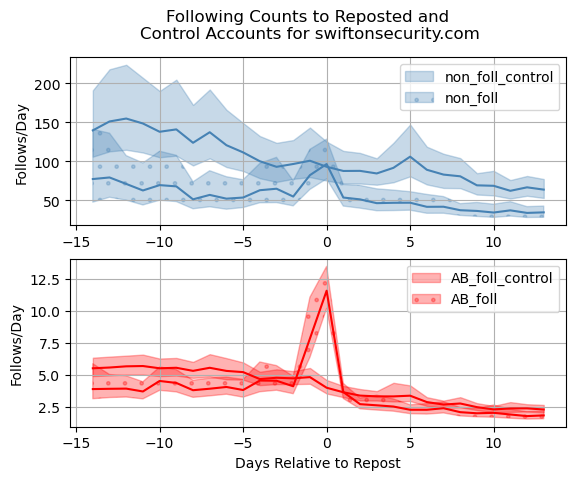

In [86]:
fig, ax = plt.subplots(2, 1)
plot_cis_and_means(dfs['control']['non'], ax[0], '#4682b4', 'non_foll_control', DENOM_NON, alpha=0.3)
plot_cis_and_means(dfs['control']['foll'], ax[1], 'red', 'AB_foll_control', DENOM_FOL, alpha=0.3)
plot_cis_and_means(dfs['did']['non'], ax[0], '#4682b4', 'non_foll', DENOM_NON, hatch='.', alpha=0.3)
plot_cis_and_means(dfs['did']['foll'], ax[1], 'red', 'AB_foll', DENOM_FOL, hatch='.', alpha=0.3)
ax[0].legend()
ax[0].grid()
ax[0].set_ylabel('Follows/Day')
ax[1].legend()
ax[1].grid()
ax[1].set_ylabel('Follows/Day')
ax[1].set_xlabel('Days Relative to Repost')
plt.suptitle(f'Following Counts to Reposted and \nControl Accounts for {HANDLE}')
plt.savefig(f'{FILEPATH}/plots/trends/{HANDLE}_unified_trends.png')

In [87]:
# make dataframe for DiD analysis; want 2 outcome variables -- one for followers and one for non-followers
# df_non['gain_rate'] = df_non['gain_rate'] / DENOM_NON
# df_foll['gain_rate'] = df_foll['gain_rate'] / DENOM_FOL

for acct_type in ['did', 'control']:
    df_non = dfs[acct_type]['non']
    df_foll = dfs[acct_type]['foll']
    df_non['gain_rate'] = df_non['gain_rate'] 
    df_foll['gain_rate'] = df_foll['gain_rate'] 

    df_wide = pd.merge(
        df_non, 
        df_foll, 
        left_on=['unit_id', 'ts'], 
        right_on=['unit_id', 'ts'], 
        suffixes=['_non', '_fol']
    )
    df_wide['period'] = df_wide['time_period_non']
    if acct_type == 'did':
        df_wide['post.treat'] = df_wide['ts'].apply(lambda b: b >= 0)
        df_wide['year_treated'] = df_wide['period'] - df_wide['ts']
    elif acct_type == 'control':
        df_wide['post.treat'] = 0
        df_wide['ts'] = 0
        df_wide['year_treated'] = 10000
    df_wide = df_wide[['period', 'post.treat', 'unit_id', 'gain_rate_fol', 'gain_rate_non', 'ts', 'year_treated']]
    df_wide.to_csv(f'{FILEPATH}/processed_{acct_type}_csvs/{HANDLE}_processed_did_data.csv')


/var/folders/8f/h3kcldy50kx99114fyyq93k00000gn/T/ipykernel_5195/2030125832.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non['gain_rate'] = df_non['gain_rate']
/var/folders/8f/h3kcldy50kx99114fyyq93k00000gn/T/ipykernel_5195/2030125832.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_foll['gain_rate'] = df_foll['gain_rate']
